# Notebook 02: Text Preprocessing

**Author:** Karan Raman  
**Purpose:** Clean and filter raw forum posts to produce an analysis-ready dataset  
**Run after:** 01_eda.ipynb
**Input:** data/processed/posts_eda.parquet  
**Output:** data/processed/posts_cleaned.parquet

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')

print('Import successful')

Import successful


## 1. Load data from EDA

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'posts_eda.parquet')
print(f'Loaded {len(df):,} posts')
df.head(3)

Loaded 29,604 posts


,Text,Opinion,Question,Answer,Sentiment,Confusion,Urgency,CourseType,forum_post_id,course_display_name,...,comment_thread_id,reads,text_length,word_count,month,hour_of_day,day_of_week,thread_start_time,response_time_hours,response_time_bin
0,Interesting! How often we say those things to ...,1,0,0,6.5,2.0,1.5,Education,5225177f2c501f0a00000015,Education/EDUC115N/How_to_Learn_Math,...,5221a8262cfae31200000001,41.0,24.0,24.0,2013-09,22.0,Monday,2013-09-02 22:55:59,0.0,< 1 hr
1,"What is \Algebra as a Math Game\"" or are you j...",0,1,0,4.0,5.0,3.5,Education,5207d0e9935dfc0e0000005e,Education/EDUC115N/How_to_Learn_Math,...,520663839df35b0a00000043,55.0,18.0,18.0,2013-08,17.0,Sunday,2013-08-11 17:59:05,0.0,< 1 hr
2,I like the idea of my kids principal who says ...,1,0,0,5.5,3.0,2.5,Education,52052c82d01fec0a00000071,Education/EDUC115N/How_to_Learn_Math,...,51e59415e339d716000001a6,25.0,28.0,28.0,2013-08,17.0,Friday,2013-08-09 17:53:06,0.0,< 1 hr


## 2. Inspect raw text
Sample posts before cleaning to understand what we are working with.

In [3]:
pd.set_option('display.max_colwidth', 300)
df[['forum_post_id', 'Text', 'post_type']].sample(10, random_state=42)

,forum_post_id,Text,post_type
27664,528a388fea8a487d21000004,"But remember that, as the two best scores from your essays are the ones that count towards the final grade, it is impossible for your overall score to be made worse by essay three - you can only improve your grade.",Comment
28750,53b6b81dc66cdc6319000033,"I have a question about sample means._x0007__x0007_You say a few times through unit 5 that the sample mean follows a t-distribution with n-1 degrees of freedom. I feel inclined to think that for a sample of size n from a normally distributed variable, the sample mean follows a normal distributio...",CommentThread
5115,5246045a01a1811200000009,"Like Jo, I think it's very crucial to stop and think about the question, to really disect it and understand what it's asking._x0007__x0007_1) Think about the question, understand it._x0007_2) Now that you've thought of the quesiton, I would say to draw it out so that you can see it, which helps ...",CommentThread
12401,52e906848da5b60607000025,"The US Constitution was ratified by all 13 states. Only 9 of the original 13 states needed to ratify the Constitution, but eventually all 13 did ratify the Constitution. The last state was in 1790.",Comment
17123,5324d5eda47ddb9b0e00001a,"No, AFAIU, wiggly generally performs better on the training data, often due to overfitting to those particular training data, but then it will perform less well on the test data.",Comment
23269,524350694afdc30e00000007,The second picture was particularly apt and fun to read. Thanks for posting.,Comment
14767,52fcc63802067d089000001c,"THE GHANA REPORT BY AVOTRI AND WALTERS._x0007_It is sad to note that women due to their emotional make up tend to worry about anyone and everything they care about even to their own detriment. After all the mental agony, the man dies and the women is exposed to the truth of even greater agony wh...",Comment
10166,52d5a801a8970a7be600002c,"One if the videos suggested directing heat to specific areas, face, armpits and hands I think._x0007__x0007_I've always given some priority to getting dry and taking in a few calories as well. And some sort of warm down rather than sudden cessation of movement, although the discussion of after d...",Comment
20149,51beb2aabf600b160000006d,"You can try reproducing the lecture calculations for risk, rate, etc. in R if you would like more practice. We should try putting examples of how to do this up on the wiki...",Comment
16936,5320afe4cadc90b06100000f,"Not only was the subject matter fascinating, but the delivery was engaging, informative and entertaining._x0007_Thank you!",CommentThread


## 3. Noise Analysis and Text cleaning

In [4]:
# Noise analysis
# scan raw text before cleaning to understand what needs to be handled
noise_patterns = {
    'HTML tags'          : r'<[^>]+>',
    'Redacted name tags' : r'<nameRedac_[^>]*>',
    'Anon screen name'   : r'<anon_screen_name_redacted>',
    'URLs'               : r'http\S+|www\.\S+',
    'Email addresses'    : r'\S+@\S+',
    'HTML entities'      : r'&[a-z]+;',
    '_x0007_ artefacts'  : r'_x0007_',
    'Markdown links'     : r'\[.*?\]\(.*?\)',
    'Broken URL fragments': r'[a-f0-9]{8,}&\S+',
    'Non-ASCII chars'    : r'[^\x00-\x7F]',
}

print('Noise pattern frequency (raw text):')
for label, pattern in noise_patterns.items():
    count = df['Text'].str.contains(pattern, regex=True, na=False).sum()
    pct   = count / len(df) * 100
    print(f'  {label:<25}: {count:>6,} ({pct:.1f}%)')

Noise pattern frequency (raw text):
  HTML tags                :  3,002 (10.1%)
  Redacted name tags       :  1,718 (5.8%)
  Anon screen name         :  1,718 (5.8%)
  URLs                     :  1,098 (3.7%)
  Email addresses          :     45 (0.2%)
  HTML entities            :      5 (0.0%)
  _x0007_ artefacts        : 10,110 (34.2%)
  Markdown links           :     21 (0.1%)
  Broken URL fragments     :      2 (0.0%)
  Non-ASCII chars          :    817 (2.8%)


In [5]:
# Text cleaning function
# handles all noise patterns identified in the analysis above

def clean_text(text):
    if not isinstance(text, str) or text.strip().lower() in ('nan', 'none', 'null', ''):
        return ''

    # nested redacted name tags must go first before general HTML removal
    text = re.sub(r'<nameRedac_<[^>]*>>', '', text)
    text = re.sub(r'<nameRedac_[^>]*>', '', text)

    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)

    # urls and links
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)
    text = re.sub(r'\[([^\]]+)\]\[[^\]]*\]', r'\1', text)

    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[a-f0-9]{8,}&\S+', '', text)
    text = text.replace('_x0007_', ' ')
    text = re.sub(r'[^\x00-\x7F]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text_clean'] = df['Text'].apply(clean_text)
print('Cleaning done.')

Cleaning done.


## 4. Filter short posts
Posts with fewer than five words are excluded as they carry no reliable politeness signal.

In [6]:
# word count after cleaning to decide the minimum length threshold

df['word_count'] = df['text_clean'].str.split().str.len()
print(df['word_count'].describe().round(1).to_string())
print()

for t in [0, 3, 5, 10]:
    n = (df['word_count'] <= t).sum()
    print(f'posts with  <= {t:>2} words: {n:,} ({n/len(df)*100:.1f}%)')

count    29604.0
mean        59.9
std         63.9
min          0.0
25%         20.0
50%         41.0
75%         76.0
max        505.0

posts with  <=  0 words: 31 (0.1%)
posts with  <=  3 words: 975 (3.3%)
posts with  <=  5 words: 1,762 (6.0%)
posts with  <= 10 words: 3,601 (12.2%)


In [7]:
# 5 words minimum is standard in the politeness literature
MIN_WORDS = 5

n_before = len(df)
df = df[df['word_count'] >= MIN_WORDS].copy()
n_after = len(df)

print(f'Removed {n_before - n_after:,} posts shorter than {MIN_WORDS} words')
print(f'Remaining posts: {n_after:,}')

Removed 1,338 posts shorter than 5 words
Remaining posts: 28,266


## 5. Standardise columns
Rename and recast columns for consistency throughout the rest of the project.

In [8]:
# standardise column names
df = df.rename(columns={
    'Text'      : 'text_raw',
    'Opinion'   : 'is_opinion',
    'Question'  : 'is_question',
    'Answer'    : 'is_answer',
    'Sentiment' : 'sentiment',
    'Confusion' : 'confusion',
    'Urgency'   : 'urgency',
    'CourseType': 'course_type',
})

# cast binary flags to integer
for col in ['is_opinion', 'is_question', 'is_answer', 'anonymous', 'anonymous_to_peers']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# parse timestamps
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')

print('Column types after standardising:')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}')

Column types after standardising:
  text_raw: str
  is_opinion: int64
  is_question: int64
  is_answer: int64
  sentiment: float64
  confusion: float64
  urgency: float64
  course_type: str
  forum_post_id: str
  course_display_name: str
  forum_uid: str
  created_at: datetime64[us, UTC]
  post_type: str
  anonymous: int64
  anonymous_to_peers: int64
  up_count: float64
  comment_thread_id: str
  reads: float64
  text_length: float64
  word_count: int64
  month: period[M]
  hour_of_day: float64
  day_of_week: str
  thread_start_time: datetime64[us]
  response_time_hours: float64
  response_time_bin: category
  text_clean: str


## 7. Response timing

In [9]:
# compute response timing for each post relative to thread start

for col in ['thread_start_time', 'response_time_hours', 'response_time_bin']:
    if col in df.columns:
        df = df.drop(columns=[col])

thread_first = (
    df.groupby('comment_thread_id')['created_at']
    .min()
    .rename('thread_start_time')
)
df = df.merge(thread_first, on='comment_thread_id', how='left')

df['response_time_hours'] = (
    df['created_at'] - df['thread_start_time']
).dt.total_seconds() / 3600

bins   = [-0.01, 1, 24, 168, float('inf')]
labels = ['< 1 hour', '1-24 hours', '1-7 days', '> 7 days']
df['response_time_bin'] = pd.cut(df['response_time_hours'], bins=bins, labels=labels)

print(f'Response time computed for {df["response_time_hours"].notna().sum():,} posts')
print(df['response_time_bin'].value_counts().reindex(labels).to_string())

Response time computed for 16,061 posts
response_time_bin
< 1 hour      8457
1-24 hours    3386
1-7 days      2760
> 7 days      1458


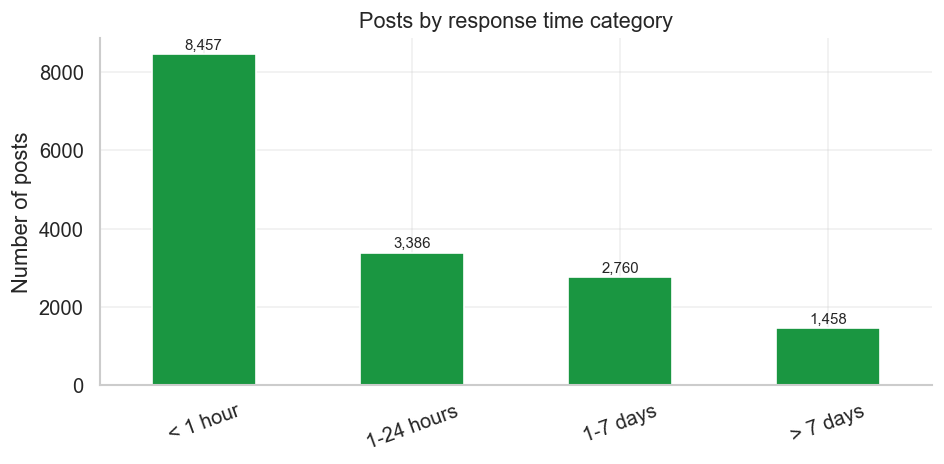

In [10]:
# response time distribution
rt_counts = df['response_time_bin'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4))
rt_counts.plot(kind='bar', ax=ax, color=GREEN, edgecolor='white')
ax.set_title('Posts by response time category')
ax.set_ylabel('Number of posts')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_response_bins.png')
plt.show()

## 8. Select final columns

In [10]:
# select final columns and save clean dataset

KEEP_COLS = [
    'forum_post_id', 'comment_thread_id', 'forum_uid',
    'course_display_name', 'course_type', 'created_at', 'post_type',
    'is_opinion', 'is_question', 'is_answer',
    'anonymous', 'anonymous_to_peers',
    'up_count', 'reads', 'sentiment', 'confusion', 'urgency',
    'text_raw', 'text_clean', 'word_count',
    'thread_start_time', 'response_time_hours', 'response_time_bin',
]

df_clean = df[KEEP_COLS].copy()
print(f'Final shape: {df_clean.shape}')
df_clean.head(3)

Final shape: (28266, 23)


,forum_post_id,comment_thread_id,forum_uid,course_display_name,course_type,created_at,post_type,is_opinion,is_question,is_answer,...,reads,sentiment,confusion,urgency,text_raw,text_clean,word_count,thread_start_time,response_time_hours,response_time_bin
0,5225177f2c501f0a00000015,5221a8262cfae31200000001,30CADB93E6DE4711193D7BD05F2AE95C,Education/EDUC115N/How_to_Learn_Math,Education,2013-09-02 22:55:59+00:00,Comment,1,0,0,...,41.0,6.5,2.0,1.5,Interesting! How often we say those things to others without really understanding what we are saying. That must have been a powerful experience! Excellent!,Interesting! How often we say those things to others without really understanding what we are saying. That must have been a powerful experience! Excellent!,24,2013-09-02 22:55:59+00:00,0.0,< 1 hour
1,5207d0e9935dfc0e0000005e,520663839df35b0a00000043,37D8FAEE7D0B94B6CFC57D98FD3D0BA5,Education/EDUC115N/How_to_Learn_Math,Education,2013-08-11 17:59:05+00:00,Comment,0,1,0,...,55.0,4.0,5.0,3.5,"What is \Algebra as a Math Game\"" or are you just saying you create games that incorporate algebra.""","What is \Algebra as a Math Game\"" or are you just saying you create games that incorporate algebra.""",18,2013-08-11 17:59:05+00:00,0.0,< 1 hour
2,52052c82d01fec0a00000071,51e59415e339d716000001a6,CC11480215042B3EB6E5905EAB13B733,Education/EDUC115N/How_to_Learn_Math,Education,2013-08-09 17:53:06+00:00,Comment,1,0,0,...,25.0,5.5,3.0,2.5,"I like the idea of my kids principal who says \Smart doesn't mean easy, smart means working hard\"" and incorporating the idea of making mistakes into working hard.""","I like the idea of my kids principal who says \Smart doesn't mean easy, smart means working hard\"" and incorporating the idea of making mistakes into working hard.""",28,2013-08-09 17:53:06+00:00,0.0,< 1 hour


## 8. Sanity check
Quick check to confirm the cleaned dataset looks as expected before saving.

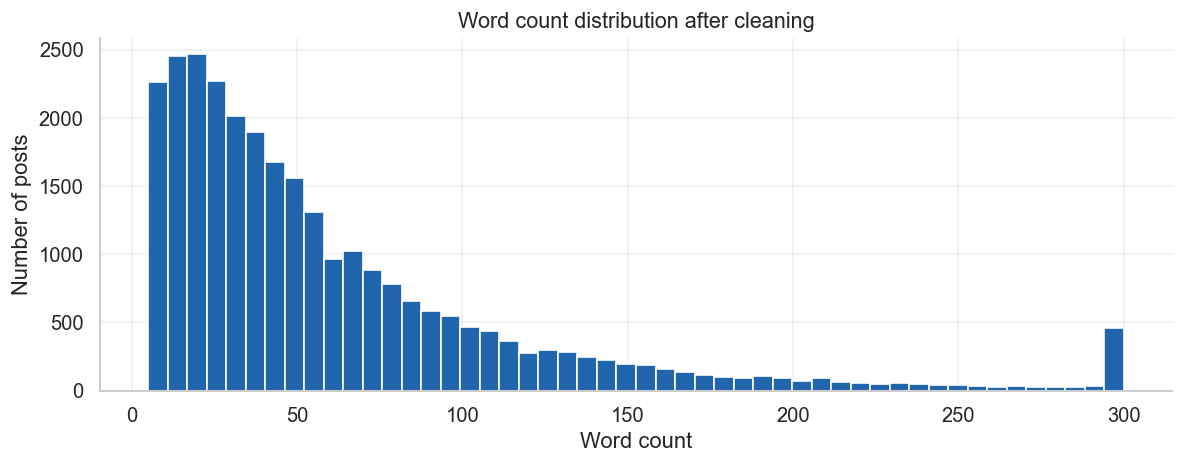

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
df_clean['word_count'].clip(upper=300).plot(kind='hist', bins=50, ax=ax, color=BLUE, edgecolor='white')
ax.set_title('Word count distribution after cleaning')
ax.set_xlabel('Word count')
ax.set_ylabel('Number of posts')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_wordcount_clean.png')
plt.show()

In [12]:
print('post_type breakdown:')
print(df_clean['post_type'].value_counts())

print('\ncourse_type breakdown:')
print(df_clean['course_type'].value_counts())

post_type breakdown:
post_type
Comment          16061
CommentThread    12188
Name: count, dtype: int64

course_type breakdown:
course_type
Education     9592
Medicine      9372
Humanities    9300
Name: count, dtype: int64


## 9. Save clean dataset

In [13]:
# save clean dataset
for col in df_clean.select_dtypes(include=['object', 'str']).columns:
    df_clean[col] = df_clean[col].astype(str)

df_clean.to_parquet(DATA_PROCESSED / 'posts_clean.parquet', index=False)
print(f'Saved {len(df_clean):,} posts to posts_clean.parquet')

Saved 28,266 posts to posts_clean.parquet
